In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all 5 files
home         = pd.read_csv('home_page_table.csv')
search       = pd.read_csv('search_page_table.csv')
payment      = pd.read_csv('payment_page_table.csv')
confirmation = pd.read_csv('payment_confirmation_table.csv')
users        = pd.read_csv('user_table.csv', on_bad_lines='skip')

# See columns and first rows of each file
for name, dataframe in [('HOME', home), ('SEARCH', search),
                         ('PAYMENT', payment), ('CONFIRMATION', confirmation),
                         ('USERS', users)]:
    print(f"\n{'='*40}")
    print(f"{name} TABLE")
    print(f"Shape: {dataframe.shape}")
    print(dataframe.head(3))
    print("Columns:", dataframe.columns.tolist())


HOME TABLE
Shape: (90400, 2)
   user_id       page
0   313593  home_page
1   468315  home_page
2   264005  home_page
Columns: ['user_id', 'page']

SEARCH TABLE
Shape: (45200, 2)
   user_id         page
0    15866  search_page
1   347058  search_page
2   577020  search_page
Columns: ['user_id', 'page']

PAYMENT TABLE
Shape: (6030, 2)
   user_id          page
0   253019  payment_page
1   310478  payment_page
2   304081  payment_page
Columns: ['user_id', 'page']

CONFIRMATION TABLE
Shape: (452, 2)
   user_id                       page
0   123100  payment_confirmation_page
1   704999  payment_confirmation_page
2   407188  payment_confirmation_page
Columns: ['user_id', 'page']

USERS TABLE
Shape: (90400, 4)
   user_id        date   device     sex
0   450007  2015-02-28  Desktop  Female
1   756838  2015-01-13  Desktop    Male
2   568983  2015-04-09  Desktop    Male
Columns: ['user_id', 'date', 'device', 'sex']


In [21]:
for name, dataframe in [('HOME', home), ('SEARCH', search),
                         ('PAYMENT', payment), ('CONFIRMATION', confirmation),
                         ('USERS', users)]:
    print(f"\n{name} missing values:")
    print(dataframe.isnull().sum())


HOME missing values:
user_id    0
page       0
dtype: int64

SEARCH missing values:
user_id    0
page       0
dtype: int64

PAYMENT missing values:
user_id    0
page       0
dtype: int64

CONFIRMATION missing values:
user_id    0
page       0
dtype: int64

USERS missing values:
user_id    0
date       0
device     0
sex        0
dtype: int64


##Data Cleaning and Feature Engineering

In [22]:
# Count users at each stage
stage_counts = {
    'Home Page'    : len(home),
    'Search Page'  : len(search),
    'Payment Page' : len(payment),
    'Confirmation' : len(confirmation)
}

funnel_df = pd.DataFrame({
    'Stage' : list(stage_counts.keys()),
    'Users' : list(stage_counts.values())
})

# Calculate drop-off and conversion rates
funnel_df['Previous Users'] = funnel_df['Users'].shift(1)
funnel_df['Drop Off Users'] = funnel_df['Previous Users'] - funnel_df['Users']
funnel_df['Conv Rate %']    = (funnel_df['Users'] / funnel_df['Previous Users'] * 100).round(1)
funnel_df['Overall %']      = (funnel_df['Users'] / funnel_df['Users'].iloc[0] * 100).round(1)

print(funnel_df[['Stage', 'Users', 'Drop Off Users', 'Conv Rate %', 'Overall %']])

          Stage  Users  Drop Off Users  Conv Rate %  Overall %
0     Home Page  90400             NaN          NaN      100.0
1   Search Page  45200         45200.0         50.0       50.0
2  Payment Page   6030         39170.0         13.3        6.7
3  Confirmation    452          5578.0          7.5        0.5


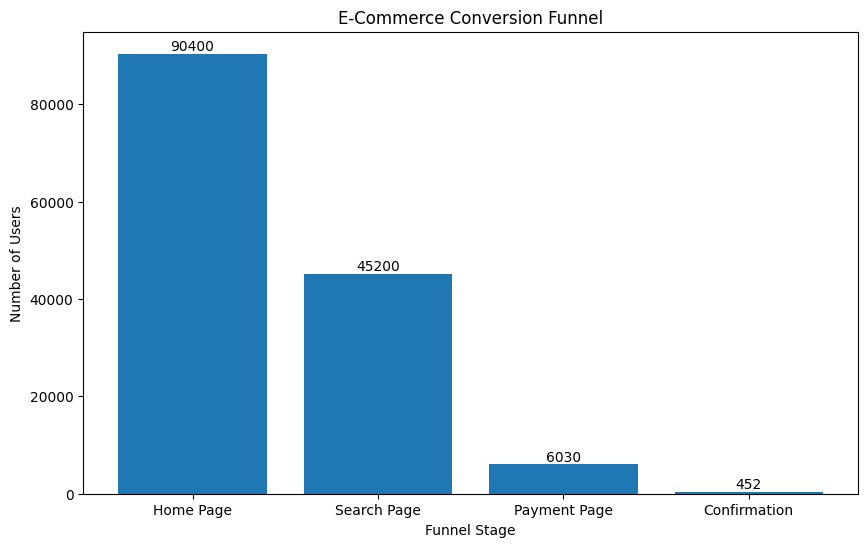

In [23]:
#Chart1:Funnel Bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bars = plt.bar(
    funnel_df['Stage'],
    funnel_df['Users'],
)

# Add labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height}', # Added the text argument 's'
        ha='center',
        va='bottom'
    )

plt.title('E-Commerce Conversion Funnel')
plt.xlabel('Funnel Stage')
plt.ylabel('Number of Users')

plt.show()

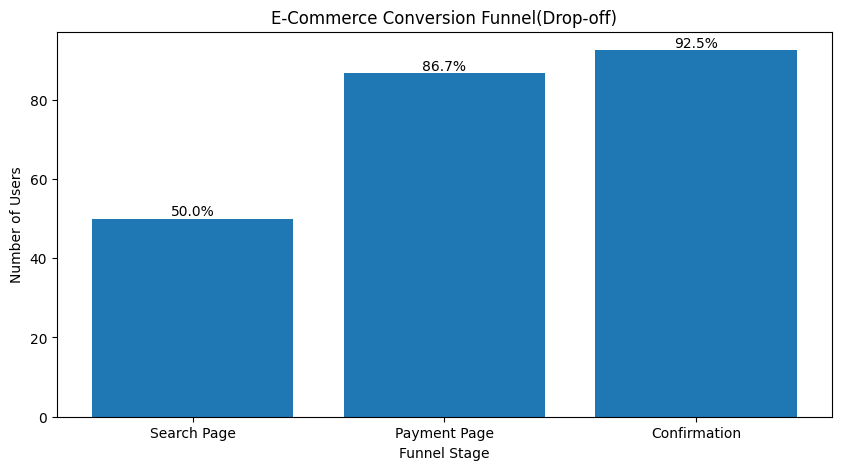

In [24]:
#Drop-off rate at each stage
dropped_df=funnel_df.dropna().copy()
dropped_df['Drop Off %']=(100-dropped_df['Conv Rate %']).round(1)

plt.figure(figsize=(10,5))

bars=plt.bar(dropped_df['Stage'], dropped_df['Drop Off %'])

for bar in bars:
    height=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, height, f'{height}'+'%', ha='center', va='bottom')

plt.title('E-Commerce Conversion Funnel(Drop-off)')
plt.xlabel('Funnel Stage')
plt.ylabel('Number of Users')

plt.show()

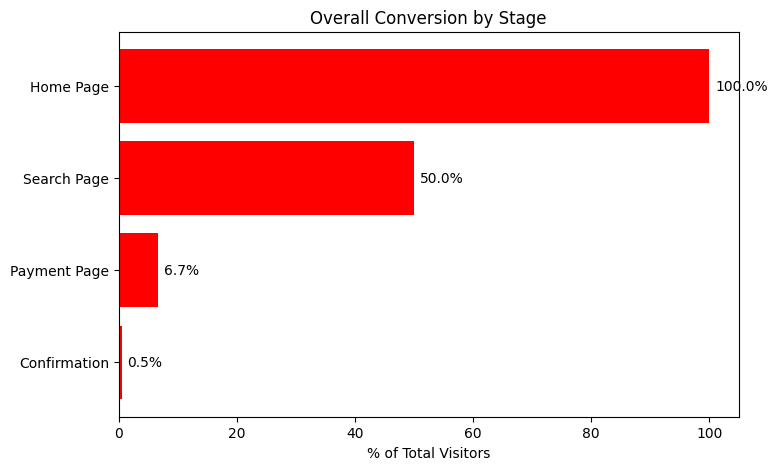

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.barh(funnel_df['Stage'], funnel_df['Overall %'], color='red')

# Add labels
for bar in bars:
    x = bar.get_width()
    y = bar.get_y() + bar.get_height()/2
    plt.text(x + 1, y, f'{x:.1f}%', va='center')

plt.title('Overall Conversion by Stage')
plt.xlabel('% of Total Visitors')

plt.gca().invert_yaxis()
plt.show()

In [26]:
#Merge with user table for gender analysis
home_users    = home.merge(users, on='user_id', how='left')
search_users  = search.merge(users, on='user_id', how='left')
payment_users = payment.merge(users, on='user_id', how='left')
conf_users    = confirmation.merge(users, on='user_id', how='left')

# Check merge worked
print("Home with gender:", home_users.shape)
print(home_users.head(3))
print("\nGender values:", home_users['sex'].value_counts())

Home with gender: (90400, 5)
   user_id       page        date   device     sex
0   313593  home_page  2015-02-26  Desktop  Female
1   468315  home_page  2015-02-21  Desktop    Male
2   264005  home_page  2015-03-25  Desktop  Female

Gender values: sex
Male      45325
Female    45075
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128105 (\N{WOMAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


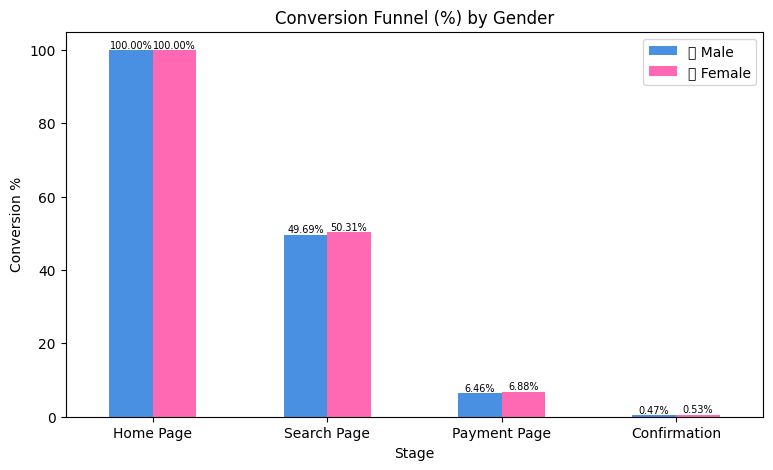

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Total users at Home Page
male_total = (home_users['sex'] == 'Male').sum()
female_total = (home_users['sex'] == 'Female').sum()

# Conversion percentages
gender_conv = pd.DataFrame({
    '👨 Male': [
        (home_users['sex'] == 'Male').sum() / male_total * 100,
        (search_users['sex'] == 'Male').sum() / male_total * 100,
        (payment_users['sex'] == 'Male').sum() / male_total * 100,
        (conf_users['sex'] == 'Male').sum() / male_total * 100
    ],

    '👩 Female': [
        (home_users['sex'] == 'Female').sum() / female_total * 100,
        (search_users['sex'] == 'Female').sum() / female_total * 100,
        (payment_users['sex'] == 'Female').sum() / female_total * 100,
        (conf_users['sex'] == 'Female').sum() / female_total * 100
    ]
},

index=['Home Page', 'Search Page', 'Payment Page', 'Confirmation'])

# Plot
ax = gender_conv.plot(
    kind='bar',
    figsize=(9, 5),
    color=['#4A90E2', '#FF69B4']
)

# Labels
for bar in ax.patches:
    y = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{y:.2f}%',
        ha='center',
        va='bottom',
        fontsize='7'
    )

plt.title('Conversion Funnel (%) by Gender')
plt.xlabel('Stage')
plt.ylabel('Conversion %')

plt.xticks(rotation=0)

plt.show()

Male Conversion Rate    : 0.47%
Female Conversion Rate  : 0.53%


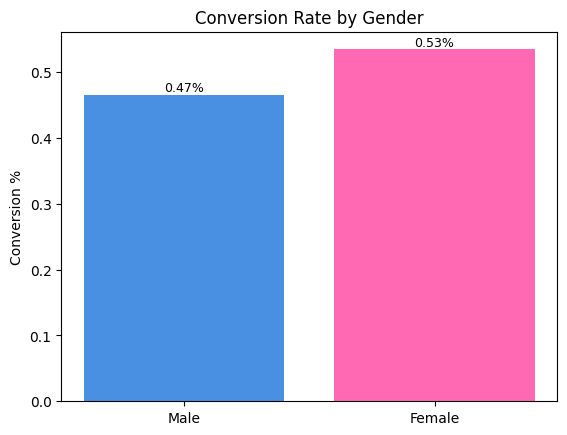

In [30]:
import matplotlib.pyplot as plt

# Conversion rates
male_rate = (
    (conf_users['sex'] == 'Male').sum() /
    (home_users['sex'] == 'Male').sum()
) * 100

female_rate = (
    (conf_users['sex'] == 'Female').sum() /
    (home_users['sex'] == 'Female').sum()
) * 100

print(f"Male Conversion Rate    : {male_rate:.2f}%")
print(f"Female Conversion Rate  : {female_rate:.2f}%")

# Plot
rates = [male_rate, female_rate]

bars = plt.bar(
    ['Male', 'Female'],
    rates,
    color=['#4A90E2', '#FF69B4']
)

# Add labels
for bar in bars:
    y = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y ,
        f'{y:.2f}%',
        ha='center',
        va='bottom',
        fontsize=9         # smaller text size
    )

plt.title('Conversion Rate by Gender')
plt.ylabel('Conversion %')

plt.show()

In [37]:
total_visitors  = len(home)
total_buyers    = len(confirmation)
overall_conv    = round(total_buyers / total_visitors * 100, 2)

# Find biggest drop-off stage
worst_idx   = funnel_df['Drop Off Users'].idxmax()
worst_stage = funnel_df.loc[worst_idx, 'Stage']
worst_drop  = int(funnel_df.loc[worst_idx, 'Drop Off Users'])

print("=" * 45)
print("         KEY KPIs — FUNNEL ANALYSIS")
print("=" * 45)
print(f"Total Visitors          : {total_visitors:,}")
print(f"Total Buyers            : {total_buyers:,}")
print(f"Overall Conversion Rate : {overall_conv}%")
print(f"Users Lost in Funnel    : {total_visitors - total_buyers:,}")
print(f"Biggest Drop-Off Stage  : {worst_stage}")
print(f"Users Lost at that Stage: {worst_drop:,}")
print(f"Male Conversion Rate    : {male_rate:.2f}%")
print(f"Female Conversion Rate  : {female_rate:.2f}%")
print("=" * 45)

         KEY KPIs — FUNNEL ANALYSIS
Total Visitors          : 90,400
Total Buyers            : 452
Overall Conversion Rate : 0.5%
Users Lost in Funnel    : 89,948
Biggest Drop-Off Stage  : Search Page
Users Lost at that Stage: 45,200
Male Conversion Rate    : 0.47%
Female Conversion Rate  : 0.53%


<h1>KEY FINDINGS</h1>

<h2>1. Overall Conversion Rate</h2>
<p>
Only <b>0.5%</b> of users who visited the Home Page completed a purchase.
This indicates that a large portion of users drop before reaching the final confirmation stage.
</p>

<h2>2. Biggest Drop-Off Stage</h2>
<p>
The highest drop-off occurs at the <b>Confirmation</b> stage.
This stage is the biggest bottleneck in the customer journey and should be prioritized for improvement.
</p>

<h2>3. Gender Insight</h2>
<p>👨 Male Conversion Rate: <b>0.47%</b></p>
<p>👩 Female Conversion Rate: <b>0.53%</b></p>

<p>
Male users have a slightly lower conversion rate compared to female users.
</p>

<h2>4. Funnel Health</h2>
<p>
A total of <b>89,948</b> users were lost between the Home Page and final purchase stage.
Even recovering a small percentage of these lost users could significantly increase overall sales and revenue.
</p>

<hr>

<h1>BUSINESS RECOMMENDATIONS</h1>

<h2>1. Improve the Biggest Drop-Off Stage</h2>
<p>
Focus on optimizing the <b>Confirmation</b> stage first, since fixing the largest leak in the funnel can provide the highest business impact.
</p>

<h2>2. Simplify the User Journey</h2>
<p>
Improve navigation and search experience so users can find products more quickly and easily.
</p>

<h2>3. Reduce Payment Friction</h2>
<ul>
  <li>Reduce unnecessary form fields</li>
  <li>Improve page speed</li>
  <li>Offer multiple payment options</li>
</ul>

<h2>4. Use Targeted Marketing Strategies</h2>
<p>
Create targeted campaigns and personalized experiences for male users to improve engagement and conversion.
</p>